In [29]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import train_mlp, train_mlp_grid_search
from ml_baselines.config import Config

In [30]:
cfg = Config()
site = "MHD"

Manually train an MLP model

In [ ]:
params_dict = {'activation': 'relu',
               'alpha': 0.0001,
               'batch_size': 10,
               'early_stopping': True,
               'hidden_layer_sizes': (50),
               'learning_rate': "constant",
               'learning_rate_init': 0.0001,
               'shuffle': False,
               'max_iter': 1000,
               'solver': 'adam'}

model, x, y = train_mlp("MHD",
                        balance=-1,
                        time_shift_hours=[24, 72],
                        mlp_params=params_dict)

Training MLP model for site: MHD
Number of training points: 13116
... number of baseline points: 3161 (24.1%)
... fitting
... predicting
Precision on Training Set = 0.621
Precision on Validation Set = 0.540
Precision on Test Set = 0.604
Recall on Training Set = 0.565
Recall on Validation Set = 0.562
Recall on Test Set = 0.567
F1 Score on Training Set = 0.592
F1 Score on Validation Set = 0.551
F1 Score on Test Set = 0.585


In [ ]:
# Save model
# met_str = f"-{cfg.met_type}" if cfg.met_type else ""
# joblib.dump(model, Path(cfg.models_path) / f"mlp{met_str}_{site}.joblib")

['/Users/chxmr/code/ml-baselines/models/mlp-arco-era5_MHD.joblib']

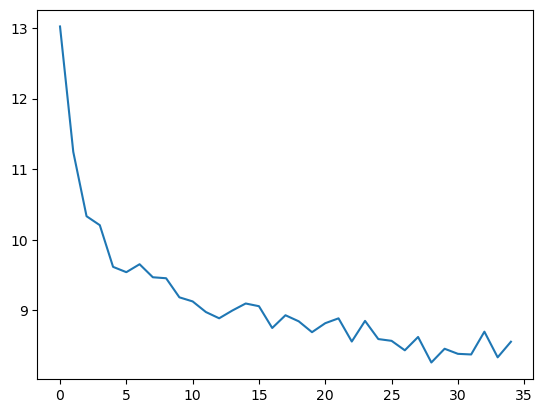

In [32]:
plt.plot(model.loss_curve_)

Run a grid search, including balancing

In [35]:
grid_search = train_mlp_grid_search("MHD",
                                    param_grid={'activation': ['relu'],
                                            'alpha': [0.0001],
                                            'batch_size': [5, 10],
                                            'early_stopping': [True],
                                            'hidden_layer_sizes': [(50)],
                                            'learning_rate': ["constant"],
                                            'learning_rate_init': [0.0001],
                                            'shuffle': [False],
                                            'max_iter': [1000],
                                            'solver': ['adam']},
                                    data_kwargs={'time_shift_hours': [[24, 72],
                                                                      [24],
                                                                      [6]]},
                                    validation_keys=["time_shift_hours"],)

... data kwargs: {'time_shift_hours': [24, 72]}
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, totalling 2 fits
[CV] END activation=relu, alpha=0.0001, batch_size=10, early_stopping=True, hidden_layer_sizes=50, learning_rate=constant, learning_rate_init=0.0001, max_iter=1000, shuffle=False, solver=adam; total time=   5.0s
[CV] END activation=relu, alpha=0.0001, batch_size=5, early_stopping=True, hidden_layer_sizes=50, learning_rate=constant, learning_rate_init=0.0001, max_iter=1000, shuffle=False, solver=adam; total time=  17.1s
Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 5, 'early_stopping': True, 'hidden_layer_sizes': 50, 'learning_rate': 'constant', 'learning_rate_init': 0.0001, 'max_iter': 1000, 'shuffle': False, 'solver': 'adam'}
Best score:  0.4919292851652574
... data kwargs: {'time_shift_hours': [24]}
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, to